# End-to-End Training Dataflow Audit (Masked Latent Index)

This notebook audits the complete training data flow with **exact config**:

`/home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py`

The audit is segmented by stages/modules:
1. Config and datamodule wiring
2. TFRecord parse stage (pre-augmentation)
3. Multicrop augmentation + masking invariants
4. Torch loader conversion path
5. Attention mask policy (`masked_query_to_unmasked_kv`)
6. Student/teacher latent prediction path
7. One non-compiled training step with optimizer/scheduler

All checks are executed on real data and produce explicit pass/fail summaries.


In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("Project root:", ROOT)


Project root: /home/wuhao/spectra-learning


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from ml_collections import config_dict

from utils.training import load_config, build_model_from_config
from input_pipeline import TfLightningDataModule, _build_dataset, numpy_batch_to_torch
from networks.transformer_torch import build_masked_attention_allow_matrix
from train import _build_optimizers, _resolve_autocast_dtype, _train_step_impl


In [3]:
CONFIG_PATH = Path('/home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py')
cfg = load_config(CONFIG_PATH)

print("Config path:", CONFIG_PATH)
print("dataset:", cfg.dataset)
print("batch_size:", cfg.batch_size)
print("num_views:", cfg.multicrop_num_global_views + cfg.multicrop_num_local_views)
print("use_masked_token_input:", cfg.use_masked_token_input)
print("masked_token_position_mode:", cfg.masked_token_position_mode)
print("masked_token_attention_mode:", cfg.masked_token_attention_mode)
print("masked_token_loss_weight:", cfg.masked_token_loss_weight)
print("multicrop_keep_masked_tokens:", cfg.multicrop_keep_masked_tokens)


Config path: /home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py
dataset: gems_a
batch_size: 256
num_views: 6
use_masked_token_input: True
masked_token_position_mode: index
masked_token_attention_mode: masked_query_to_unmasked_kv
masked_token_loss_weight: 1.0
multicrop_keep_masked_tokens: True


In [4]:
dm = TfLightningDataModule(cfg, seed=int(cfg.seed))

print("DataModule info:")
for k, v in dm.info.items():
    print(f"  {k}: {v}")

print("\nStep counts:")
for k, v in dm.steps.items():
    print(f"  {k}: {v}")


DataModule info:
  tfrecord_dir: /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord
  train_size: 39854312
  validation_size: 2097596
  massspec_train_size: 194119
  massspec_val_size: 19429
  massspec_test_size: 17556
  massspec_metadata_version: 3
  massspec_adduct_vocab: {'unknown': 0, '[M+H]+': 1, '[M+Na]+': 2}
  massspec_instrument_type_vocab: {'unknown': 0, 'Orbitrap': 1, 'QTOF': 2}
  massspec_adduct_vocab_size: 3
  massspec_instrument_type_vocab_size: 3
  num_peaks: 60
  mz_representation: mz
  fingerprint_bits: 1024
  max_precursor_mz: 1000.0
  peak_mz_min: 20.0
  peak_mz_max: 1000.0

Step counts:
  gems_train: 155680
  gems_val: 8194
  gems_test: 8194
  massspec_train: 758
  massspec_val: 76
  massspec_test: 69


## Stage 1: TFRecord Parse (Pre-Augmentation)

In [5]:
raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=10_000,
    seed=int(cfg.seed),
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    augmentation_type='none',
    peak_ordering=cfg.peak_ordering,
)
raw_batch = next(raw_ds.as_numpy_iterator())

print("Raw keys:", sorted(raw_batch.keys()))
for k, v in raw_batch.items():
    if hasattr(v, 'shape'):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")


Raw keys: ['intensity', 'mz', 'peak_intensity', 'peak_mz', 'peak_valid_mask', 'precursor_mz', 'rt']
  peak_mz: shape=(16, 60), dtype=float32
  peak_intensity: shape=(16, 60), dtype=float32
  peak_valid_mask: shape=(16, 60), dtype=bool
  precursor_mz: shape=(16,), dtype=float32
  rt: shape=(16,), dtype=float32
  mz: shape=(16, 60), dtype=float32
  intensity: shape=(16, 60), dtype=float32


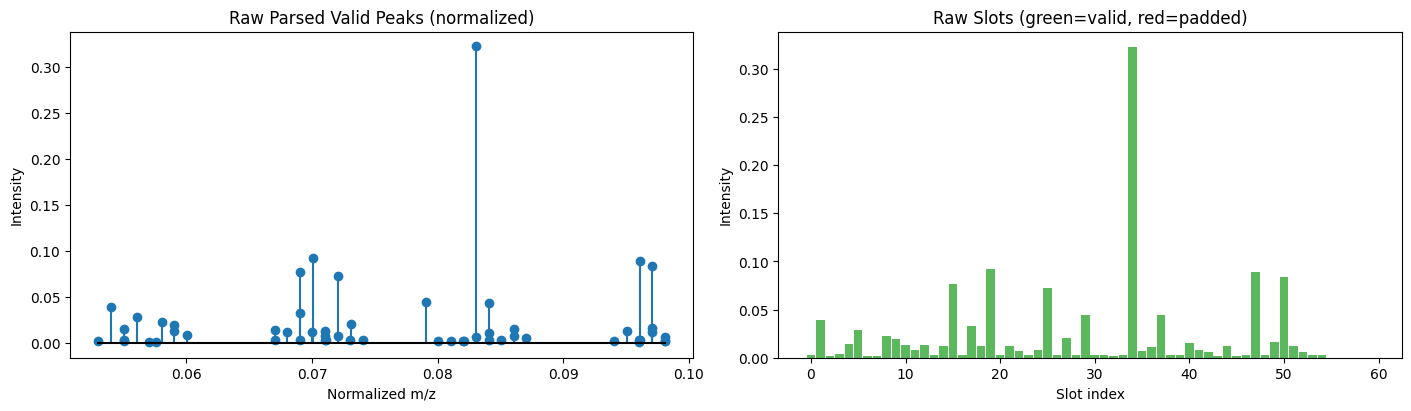

In [6]:
idx = 0
mz = raw_batch['peak_mz'][idx]
intensity = raw_batch['peak_intensity'][idx]
valid = raw_batch['peak_valid_mask'][idx].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

axes[0].stem(mz[valid], intensity[valid], linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[0].set_title('Raw Parsed Valid Peaks (normalized)')
axes[0].set_xlabel('Normalized m/z')
axes[0].set_ylabel('Intensity')

slot = np.arange(len(valid))
slot_color = np.where(valid, '#5cb85c', '#d9534f')
axes[1].bar(slot, intensity, color=slot_color, width=0.9)
axes[1].set_title('Raw Slots (green=valid, red=padded)')
axes[1].set_xlabel('Slot index')
axes[1].set_ylabel('Intensity')

plt.savefig('notebooks/fig_dataflow_stage1_raw_parse.png', bbox_inches='tight')
plt.show()


## Stage 2: Augmented Batch -> Torch Conversion (Training-Equivalent)


In [7]:
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=int(cfg.batch_size),
    shuffle_buffer=int(cfg.shuffle_buffer),
    seed=int(cfg.seed),
    drop_remainder=bool(cfg.drop_remainder),
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    augmentation_type='multicrop',
    multicrop_num_global_views=int(cfg.multicrop_num_global_views),
    multicrop_num_local_views=int(cfg.multicrop_num_local_views),
    multicrop_global_keep_fraction=float(cfg.multicrop_global_keep_fraction),
    multicrop_local_keep_fraction=float(cfg.multicrop_local_keep_fraction),
    mz_jitter_std=float(cfg.sigreg_mz_jitter_std),
    intensity_jitter_std=float(cfg.sigreg_intensity_jitter_std),
    keep_masked_tokens=bool(cfg.multicrop_keep_masked_tokens),
    peak_ordering=cfg.peak_ordering,
)
aug_batch_np = next(aug_ds.as_numpy_iterator())
train_batch = numpy_batch_to_torch(aug_batch_np)

print("Train-equivalent batch keys:", sorted(train_batch.keys()))
for k, v in train_batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: shape={tuple(v.shape)}, dtype={v.dtype}, device={v.device}")
    else:
        print(f"  {k}: type={type(v)}")


Train-equivalent batch keys: ['fused_intensity', 'fused_masked_positions', 'fused_mz', 'fused_precursor_mz', 'fused_valid_mask', 'intensity', 'mz', 'peak_intensity', 'peak_mz', 'peak_valid_mask', 'precursor_mz', 'rt', 'view1_masked_fraction']
  peak_mz: shape=(256, 60), dtype=torch.float32, device=cpu
  peak_intensity: shape=(256, 60), dtype=torch.float32, device=cpu
  peak_valid_mask: shape=(256, 60), dtype=torch.bool, device=cpu
  precursor_mz: shape=(256,), dtype=torch.float32, device=cpu
  rt: shape=(256,), dtype=torch.float32, device=cpu
  mz: shape=(256, 60), dtype=torch.float32, device=cpu
  intensity: shape=(256, 60), dtype=torch.float32, device=cpu
  fused_mz: shape=(1536, 60), dtype=torch.float32, device=cpu
  fused_intensity: shape=(1536, 60), dtype=torch.float32, device=cpu
  fused_precursor_mz: shape=(1536,), dtype=torch.float32, device=cpu
  fused_valid_mask: shape=(1536, 60), dtype=torch.bool, device=cpu
  fused_masked_positions: shape=(1536, 60), dtype=torch.bool, devic

In [8]:
tb = {k: (v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else v) for k, v in train_batch.items()}

fused_valid = tb['fused_valid_mask'].astype(bool)
fused_masked = tb['fused_masked_positions'].astype(bool)
fused_intensity = tb['fused_intensity']
V = int(cfg.multicrop_num_global_views + cfg.multicrop_num_local_views)
B = fused_valid.shape[0] // V

checks = {}
checks['masked_subset_of_valid'] = bool(np.all((~fused_masked) | fused_valid))
checks['masked_positions_not_compacted'] = bool(np.any((~fused_masked[:, :-1]) & fused_masked[:, 1:]))
checks['masked_positions_present'] = bool(fused_masked.any())
checks['masked_intensity_retained_nonzero_fraction'] = float((fused_intensity[fused_masked] > 0.0).mean())
checks['global_masked_fraction'] = float(fused_masked[: cfg.multicrop_num_global_views * B].mean())
checks['local_masked_fraction'] = float(fused_masked[cfg.multicrop_num_global_views * B :].mean())

for k, v in checks.items():
    print(f"{k}: {v}")


masked_subset_of_valid: True
masked_positions_not_compacted: True
masked_positions_present: True
masked_intensity_retained_nonzero_fraction: 0.9985904039034968
global_masked_fraction: 0.17115885416666668
local_masked_fraction: 0.51484375


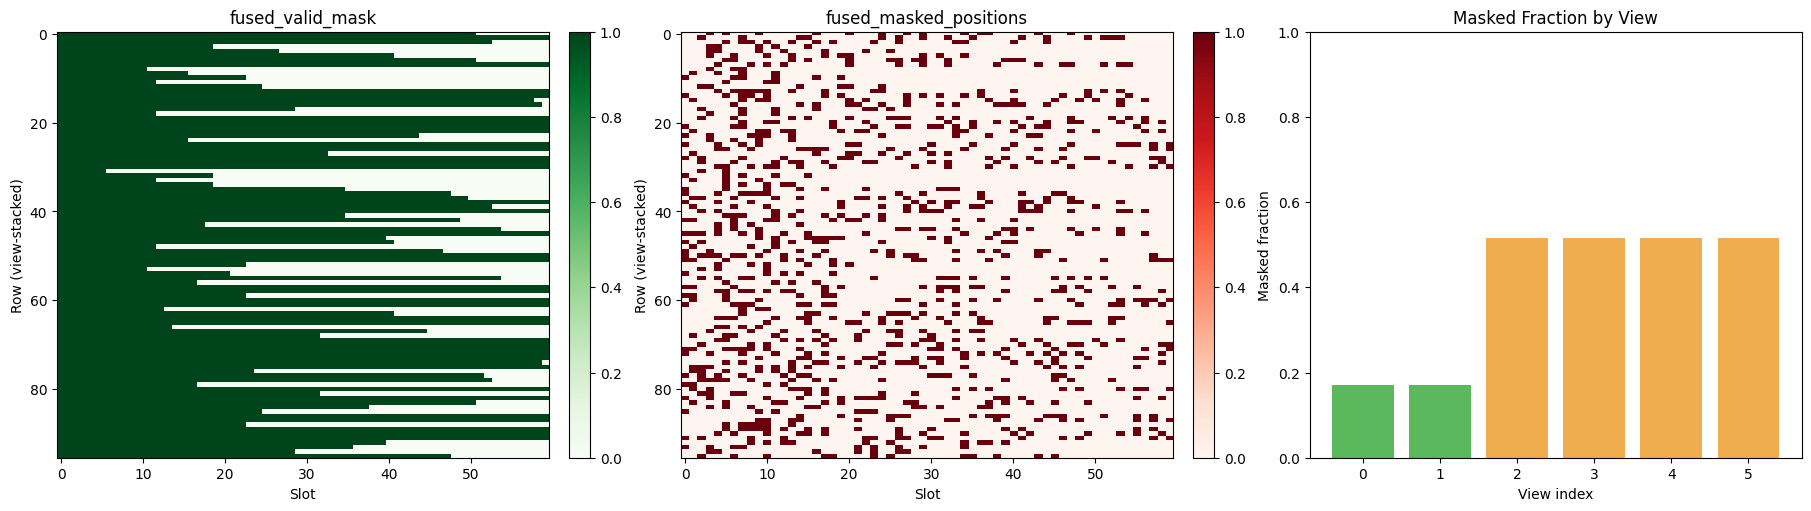

In [9]:
rows_to_show = min(96, fused_valid.shape[0])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(fused_valid[:rows_to_show].astype(float), aspect='auto', cmap='Greens', vmin=0, vmax=1)
axes[0].set_title('fused_valid_mask')
axes[0].set_xlabel('Slot')
axes[0].set_ylabel('Row (view-stacked)')

im1 = axes[1].imshow(fused_masked[:rows_to_show].astype(float), aspect='auto', cmap='Reds', vmin=0, vmax=1)
axes[1].set_title('fused_masked_positions')
axes[1].set_xlabel('Slot')
axes[1].set_ylabel('Row (view-stacked)')

view_mask_frac = []
for v in range(V):
    view_rows = fused_masked[v * B : (v + 1) * B]
    view_mask_frac.append(view_rows.mean())
axes[2].bar(np.arange(V), view_mask_frac, color=['#5cb85c'] * int(cfg.multicrop_num_global_views) + ['#f0ad4e'] * int(cfg.multicrop_num_local_views))
axes[2].set_title('Masked Fraction by View')
axes[2].set_xlabel('View index')
axes[2].set_ylabel('Masked fraction')
axes[2].set_ylim(0, 1)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.savefig('notebooks/fig_dataflow_stage2_masks_and_views.png', bbox_inches='tight')
plt.show()


## Stage 3: Attention Policy Audit (`masked_query_to_unmasked_kv`)

In [10]:
candidate_rows = np.where(fused_masked.any(axis=1))[0]
row = int(candidate_rows[0])
valid = fused_valid[row]
masked = fused_masked[row]

padding_allow = np.logical_and(valid[:, None], valid[None, :])
variant_allow = build_masked_attention_allow_matrix(
    torch.from_numpy(valid[None, :]),
    torch.from_numpy(masked[None, :]),
)[0].cpu().numpy()
blocked_edges = np.logical_and(padding_allow, ~variant_allow)

expected_block = np.logical_and(
    np.logical_and((~masked)[:, None], masked[None, :]),
    padding_allow,
)

print("selected fused row:", row)
print("valid count:", int(valid.sum()))
print("masked count:", int(masked.sum()))
print("blocked pattern matches expected:", bool(np.array_equal(blocked_edges, expected_block)))


selected fused row: 0
valid count: 51
masked count: 13
blocked pattern matches expected: True


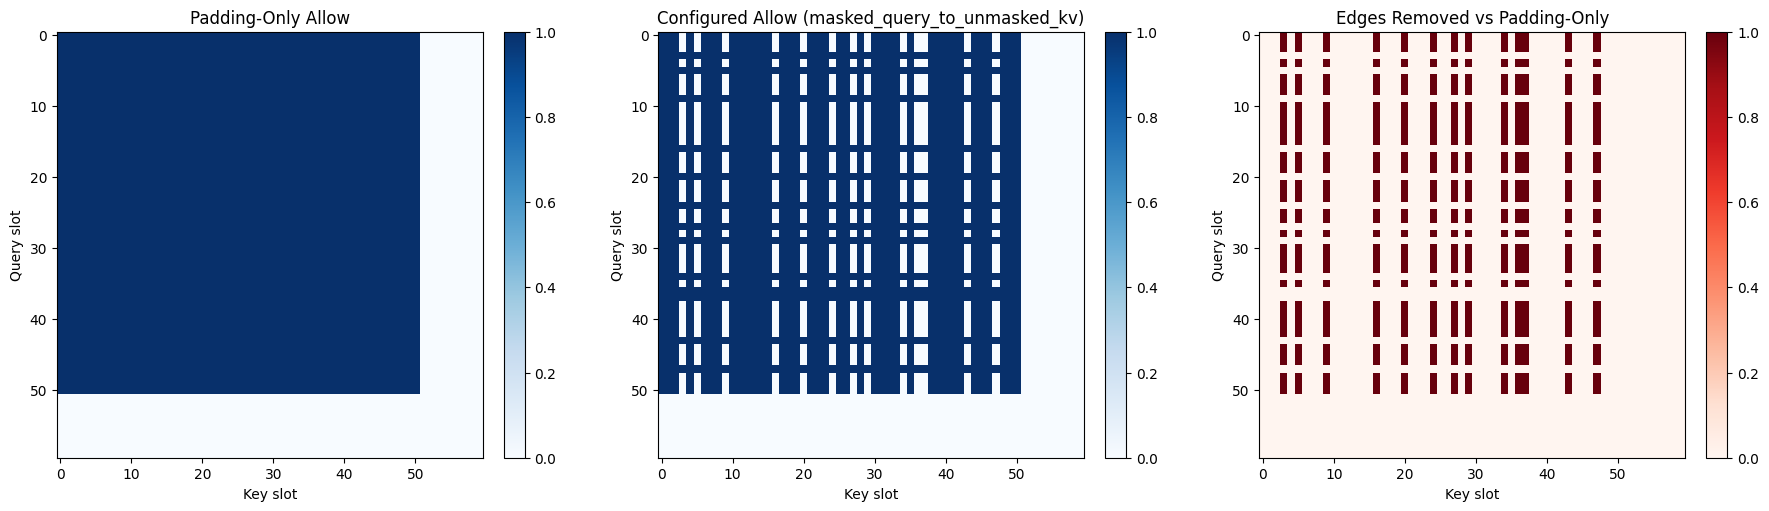

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(padding_allow.astype(float), vmin=0, vmax=1, cmap='Blues')
axes[0].set_title('Padding-Only Allow')
axes[0].set_xlabel('Key slot')
axes[0].set_ylabel('Query slot')

im1 = axes[1].imshow(variant_allow.astype(float), vmin=0, vmax=1, cmap='Blues')
axes[1].set_title('Configured Allow (masked_query_to_unmasked_kv)')
axes[1].set_xlabel('Key slot')
axes[1].set_ylabel('Query slot')

im2 = axes[2].imshow(blocked_edges.astype(float), vmin=0, vmax=1, cmap='Reds')
axes[2].set_title('Edges Removed vs Padding-Only')
axes[2].set_xlabel('Key slot')
axes[2].set_ylabel('Query slot')

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.savefig('notebooks/fig_dataflow_stage3_attention_policy.png', bbox_inches='tight')
plt.show()


## Stage 4: Model Forward Dissection (No `torch.compile`)

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = build_model_from_config(cfg).to(device)
model.eval()

cfg_bidir = config_dict.ConfigDict(cfg.to_dict())
cfg_bidir.masked_token_attention_mode = 'bidirectional'
model_bidir = build_model_from_config(cfg_bidir).to(device)
model_bidir.load_state_dict(model.state_dict(), strict=True)
model_bidir.eval()

print('model attention mode (iso):', model.encoder.masked_token_attention_mode)
print('model attention mode (bidir):', model_bidir.encoder.masked_token_attention_mode)


device: cuda


model attention mode (iso): masked_query_to_unmasked_kv
model attention mode (bidir): bidirectional


In [13]:
rows = V * 8  # keep view structure intact
small_batch = {}
for k, v in train_batch.items():
    if isinstance(v, torch.Tensor) and v.ndim > 0 and k.startswith('fused_'):
        small_batch[k] = v[:rows].to(device)
    elif isinstance(v, torch.Tensor):
        small_batch[k] = v.to(device)
    else:
        small_batch[k] = v

fused_mz_t = small_batch['fused_mz']
fused_intensity_t = small_batch['fused_intensity']
fused_valid_t = small_batch['fused_valid_mask']
fused_prec_t = small_batch['fused_precursor_mz']
fused_masked_t = small_batch['fused_masked_positions'] & fused_valid_t

student_intensity_t = fused_intensity_t.masked_fill(fused_masked_t, 0.0)

with torch.no_grad():
    student_emb = model.encoder(
        fused_mz_t,
        student_intensity_t,
        valid_mask=fused_valid_t,
        precursor_mz=fused_prec_t,
        masked_positions=fused_masked_t,
        mask_token=model.mask_token,
    )
    teacher_emb = model.encoder(
        fused_mz_t,
        fused_intensity_t,
        valid_mask=fused_valid_t,
        precursor_mz=fused_prec_t,
        masked_positions=None,
        mask_token=None,
    )
    pred_emb = model.masked_latent_predictor(student_emb)

    per_token = (pred_emb - teacher_emb).square().mean(dim=-1)
    mask_float = fused_masked_t.float()
    manual_masked_latent_loss = (per_token * mask_float).sum() / mask_float.sum()

    metrics = model.forward_augmented(small_batch)

print('manual masked_latent_loss:', float(manual_masked_latent_loss))
print('model  masked_latent_loss:', float(metrics['masked_latent_loss']))
print('absolute difference:', float((manual_masked_latent_loss - metrics['masked_latent_loss']).abs()))

print('masked slots in small batch:', int(fused_masked_t.sum().item()))
print('teacher masked-intensity > 0 fraction:', float((fused_intensity_t[fused_masked_t] > 0).float().mean().item()))
print('student masked-intensity == 0 fraction:', float((student_intensity_t[fused_masked_t] == 0).float().mean().item()))


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


manual masked_latent_loss: 1.026833176612854
model  masked_latent_loss: 1.026833176612854
absolute difference: 0.0
masked slots in small batch: 505
teacher masked-intensity > 0 fraction: 1.0
student masked-intensity == 0 fraction: 1.0


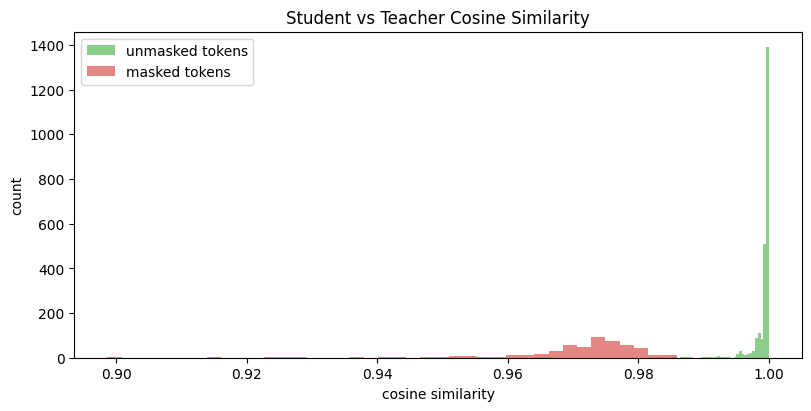

mean cosine (masked): 0.971629798412323
mean cosine (unmasked): 0.9992251396179199


In [14]:
with torch.no_grad():
    s = torch.nn.functional.normalize(student_emb, dim=-1)
    t = torch.nn.functional.normalize(teacher_emb, dim=-1)
    cos = (s * t).sum(dim=-1).detach().cpu().numpy()
    masked_np = fused_masked_t.detach().cpu().numpy().astype(bool)

masked_cos = cos[masked_np]
unmasked_cos = cos[~masked_np]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.hist(unmasked_cos, bins=40, alpha=0.7, label='unmasked tokens', color='#5cb85c')
ax.hist(masked_cos, bins=40, alpha=0.7, label='masked tokens', color='#d9534f')
ax.set_title('Student vs Teacher Cosine Similarity')
ax.set_xlabel('cosine similarity')
ax.set_ylabel('count')
ax.legend()

plt.savefig('notebooks/fig_dataflow_stage4_student_teacher_similarity.png', bbox_inches='tight')
plt.show()

print('mean cosine (masked):', float(masked_cos.mean()))
print('mean cosine (unmasked):', float(unmasked_cos.mean()))


## Stage 5: Mask-Token Contamination Check (Isolation vs Bidirectional)

In [15]:
def unmasked_output_shift_when_mask_token_perturbed(model_obj, batch_dict):
    fused_mz = batch_dict['fused_mz']
    fused_intensity = batch_dict['fused_intensity']
    fused_valid = batch_dict['fused_valid_mask']
    fused_prec = batch_dict['fused_precursor_mz']
    fused_masked = batch_dict['fused_masked_positions'] & fused_valid

    student_intensity = fused_intensity.masked_fill(fused_masked, 0.0)

    with torch.no_grad():
        out_before = model_obj.encoder(
            fused_mz,
            student_intensity,
            valid_mask=fused_valid,
            precursor_mz=fused_prec,
            masked_positions=fused_masked,
            mask_token=model_obj.mask_token,
        )
        saved = model_obj.mask_token.detach().clone()
        model_obj.mask_token.data.add_(5.0)
        out_after = model_obj.encoder(
            fused_mz,
            student_intensity,
            valid_mask=fused_valid,
            precursor_mz=fused_prec,
            masked_positions=fused_masked,
            mask_token=model_obj.mask_token,
        )
        model_obj.mask_token.data.copy_(saved)

    unmasked = (~fused_masked)
    masked = fused_masked
    unmasked_diff = (out_before[unmasked] - out_after[unmasked]).abs().mean().item()
    masked_diff = (out_before[masked] - out_after[masked]).abs().mean().item()
    return unmasked_diff, masked_diff

iso_unmasked_diff, iso_masked_diff = unmasked_output_shift_when_mask_token_perturbed(model, small_batch)
bi_unmasked_diff, bi_masked_diff = unmasked_output_shift_when_mask_token_perturbed(model_bidir, small_batch)

print('Isolation mode  | unmasked shift:', iso_unmasked_diff, '| masked shift:', iso_masked_diff)
print('Bidirectional   | unmasked shift:', bi_unmasked_diff, '| masked shift:', bi_masked_diff)


Isolation mode  | unmasked shift: 0.0 | masked shift: 0.9161103963851929
Bidirectional   | unmasked shift: 0.2783925235271454 | masked shift: 0.9240008592605591


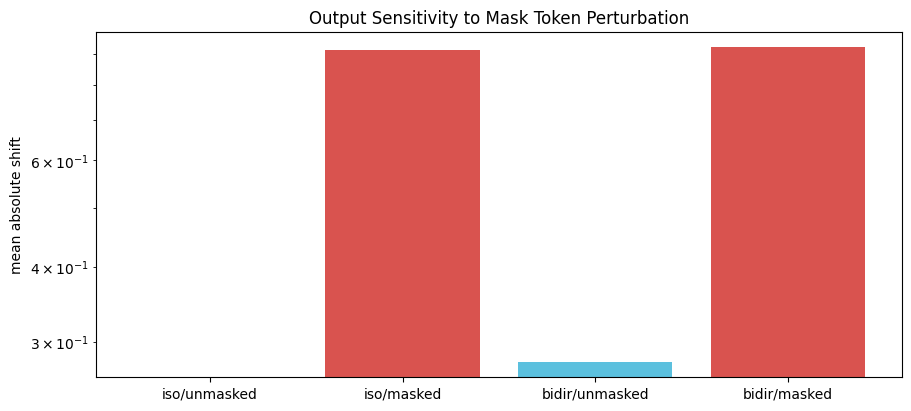

In [16]:
labels = ['iso/unmasked', 'iso/masked', 'bidir/unmasked', 'bidir/masked']
vals = [iso_unmasked_diff, iso_masked_diff, bi_unmasked_diff, bi_masked_diff]
colors = ['#5bc0de', '#d9534f', '#5bc0de', '#d9534f']

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.bar(labels, vals, color=colors)
ax.set_title('Output Sensitivity to Mask Token Perturbation')
ax.set_ylabel('mean absolute shift')
ax.set_yscale('log')

plt.savefig('notebooks/fig_dataflow_stage5_mask_token_contamination.png', bbox_inches='tight')
plt.show()


## Stage 6: One Non-Compiled Training Step

In [17]:
model_train = build_model_from_config(cfg).to(device)
model_train.train()

autocast_dtype = _resolve_autocast_dtype(cfg)
optimizers, schedulers = _build_optimizers(
    cfg,
    model_train,
    total_steps=20,
    device=device,
)

step_batch = {}
for k, v in small_batch.items():
    if isinstance(v, torch.Tensor):
        step_batch[k] = v.clone().detach()
    else:
        step_batch[k] = v

tracked = {
    'mask_token': model_train.mask_token.detach().clone(),
    'predictor_out_w': model_train.masked_latent_predictor[-1].weight.detach().clone(),
    'embedder_w0': model_train.encoder.embedder.mlp[0].weight.detach().clone(),
}

metrics_step = _train_step_impl(
    model_train,
    step_batch,
    optimizers,
    schedulers,
    autocast_dtype,
)

updates = {
    'mask_token_update_l2': float((model_train.mask_token.detach() - tracked['mask_token']).pow(2).sum().sqrt().item()),
    'predictor_out_w_update_l2': float((model_train.masked_latent_predictor[-1].weight.detach() - tracked['predictor_out_w']).pow(2).sum().sqrt().item()),
    'embedder_w0_update_l2': float((model_train.encoder.embedder.mlp[0].weight.detach() - tracked['embedder_w0']).pow(2).sum().sqrt().item()),
}

step_metrics_print = {k: float(v.detach().cpu().item()) for k, v in metrics_step.items() if torch.is_tensor(v)}

print('Step metrics:')
for k in sorted(step_metrics_print):
    print(f'  {k}: {step_metrics_print[k]:.6f}')

print('\nTracked parameter update norms:')
for k, v in updates.items():
    print(f'  {k}: {v:.6e}')


Step metrics:
  alignment: 0.050101
  encoder_pooled_raw_rms: 0.416777
  encoder_pooled_rms: 0.999971
  encoder_variance: 0.068346
  encoder_variance_raw: 0.011853
  invariance_loss: 0.073988
  loss: 1.339748
  masked_fraction: 0.175347
  masked_latent_loss: 1.018259
  pool_norm_weight_abs_mean: 1.000000
  representation_variance: 0.097550
  sigreg_loss: 2.549000
  uniformity: 0.164248
  valid_fraction: 0.701042

Tracked parameter update norms:
  mask_token_update_l2: 4.799982e-03
  predictor_out_w_update_l2: 2.033388e-03
  embedder_w0_update_l2: 9.697391e-04


## Stage 7: Consolidated Audit Summary

In [18]:
summary = {
    'masked_subset_of_valid': checks['masked_subset_of_valid'],
    'masked_positions_not_compacted': checks['masked_positions_not_compacted'],
    'masked_positions_present': checks['masked_positions_present'],
    'attention_block_pattern_exact': bool(np.array_equal(blocked_edges, expected_block)),
    'manual_vs_model_masked_loss_close': float((manual_masked_latent_loss - metrics['masked_latent_loss']).abs().item()) < 1e-6,
    'iso_mode_unmasked_contamination_low': iso_unmasked_diff < 1e-6,
    'bidir_mode_unmasked_contamination_higher_than_iso': bi_unmasked_diff > iso_unmasked_diff,
    'masked_teacher_has_signal': float((fused_intensity_t[fused_masked_t] > 0).float().mean().item()) > 0.99,
    'student_masked_is_zeroed': float((student_intensity_t[fused_masked_t] == 0).float().mean().item()) > 0.99,
    'train_step_loss_finite': np.isfinite(step_metrics_print['loss']),
}

summary_df = pd.DataFrame({
    'check': list(summary.keys()),
    'pass': list(summary.values()),
})

print(summary_df.to_string(index=False))


                                            check  pass
                           masked_subset_of_valid  True
                   masked_positions_not_compacted  True
                         masked_positions_present  True
                    attention_block_pattern_exact  True
                manual_vs_model_masked_loss_close  True
              iso_mode_unmasked_contamination_low  True
bidir_mode_unmasked_contamination_higher_than_iso  True
                        masked_teacher_has_signal  True
                         student_masked_is_zeroed  True
                           train_step_loss_finite  True
